In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np

We want to reproduce the [following chart from the DatavizProject](https://datavizproject.com/data-type/lollipop-chart/): 

<img src="https://datavizproject.com/wp-content/uploads/types/Lollipop-Chart.png" width=500 />


Remark: In each cell we will create a **new** figure object, and in all cells I reuse the same names, so we keep overwriting the variables. But you can create many figure objects in parallel if you need (e.g. `fig1`, `fig2`). 

Let's go step by step: 
- read in the data 
- draw the points on top
- draw the stems (vertical lines)
- use the correct colors 

## Step 1: read in the data 

Read in the dummy data: 

In [2]:
df = pd.read_csv('lollipop_data.csv')

In [3]:
df

,var1,var2
0,A,180
1,B,520
2,C,810
3,D,270
4,E,780
5,F,830


## Step 2: create the points 

Approach 1: scatter plot

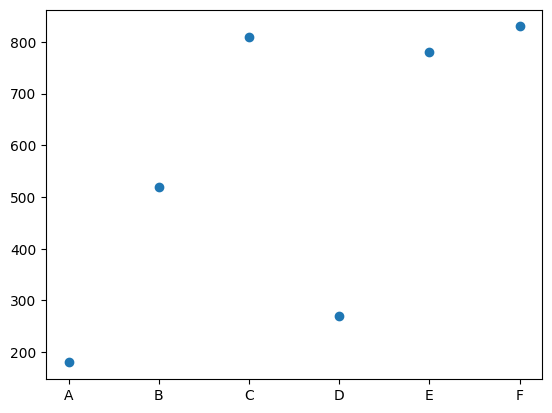

In [4]:
f, ax = plt.subplots()

ax.scatter(x=df['var1'], y=df['var2'])

In [5]:
ax.get_children()

 Text(0.5, 1.0, ''),
 Text(0.0, 1.0, ''),
 Text(1.0, 1.0, ''),

Approach 2: modified line plot 

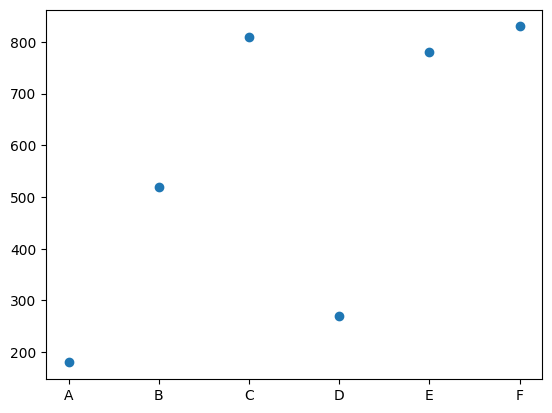

In [6]:
f, ax = plt.subplots()

# ax.plot(df['var1'], df['var2'])
ax.plot(df['var1'], df['var2'], 'o')

In [7]:
ax.get_children()

 Text(0.5, 1.0, ''),
 Text(0.0, 1.0, ''),
 Text(1.0, 1.0, ''),

## Step 3: create the stems

Prototype the stems using `ax.plot()`:

In [8]:
df

,var1,var2
0,A,180
1,B,520
2,C,810
3,D,270
4,E,780
5,F,830


A single stem: 

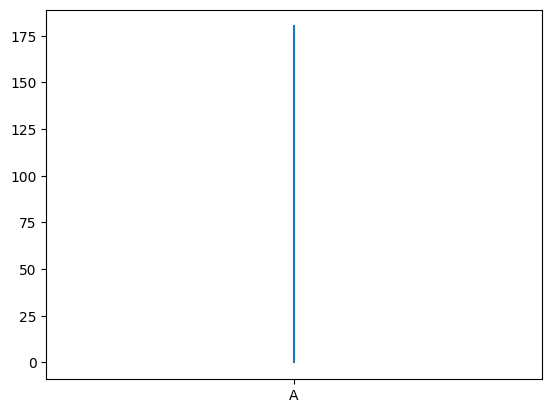

In [9]:
f, ax = plt.subplots()

# draw the lines - naive solution
ax.plot(
        [df['var1'][0], df['var1'][0]], # my x-values: 'A', 'A'
        [0,df['var2'][0]]  # my y-values: 0, 180
) 

We can add more plots: 

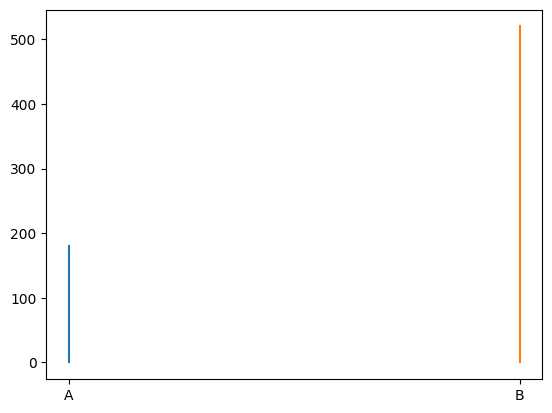

In [10]:
f, ax = plt.subplots()

ax.plot([df['var1'][0], df['var1'][0]], 
        [0,df['var2'][0]])

ax.plot([df['var1'][1], df['var1'][1]], 
        [0,df['var2'][1]])


With each overplotted plot, mpl changes the colors (-> "cycler"), because it interprets it as a next trace

Let's use a loop for this: 

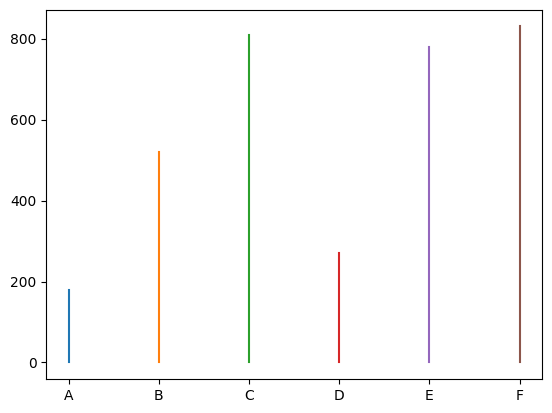

In [11]:
f, ax = plt.subplots()

for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]])


We could also use more advanced pandas functions to iterate through the contents, but let's keep it simple for now. 

## Step 4: style the plot 

Style the plot: 

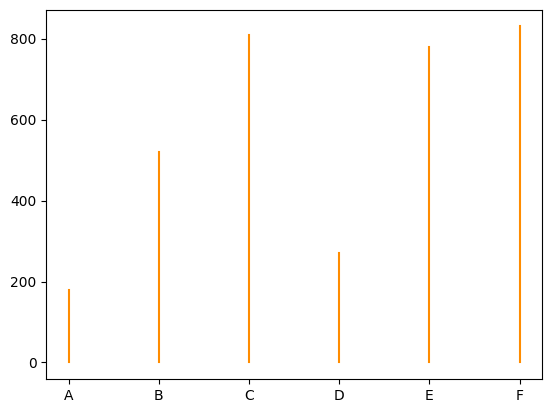

In [12]:
f, ax = plt.subplots()

# draw the lines - naive solution
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
            c='darkorange')


Save the styling in a separate variable: 

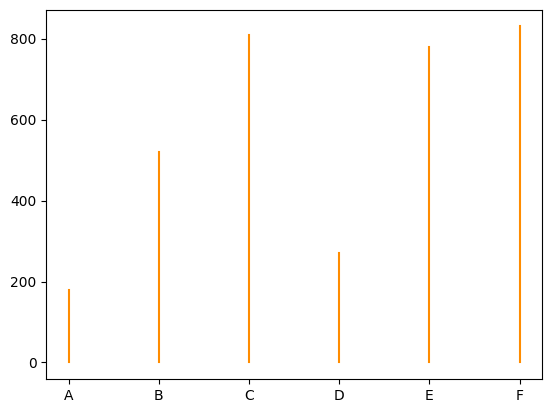

In [13]:
f, ax = plt.subplots()

# style the plot
style = {'c': 'darkorange'}

# draw the stems
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
           **style)


Read more about the unpacking operator: 

- https://realpython.com/python-kwargs-and-args/ 
- https://www.shecancode.io/blog/unpacking-function-arguments-in-python 

Let's put it all together: 

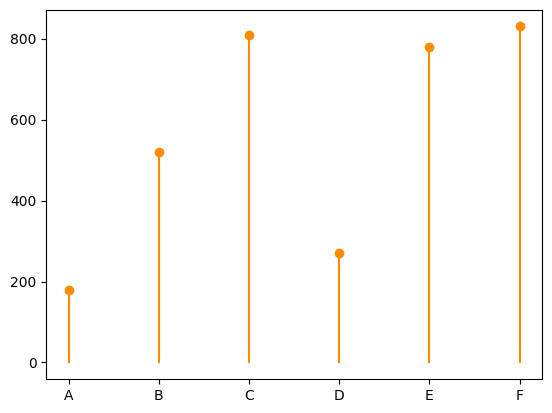

In [14]:
f, ax = plt.subplots()

# style the plot
style = {'c': 'darkorange'}

# draw the stems
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
           **style)

# draw the ends 
ax.scatter(x=df['var1'], y=df['var2'], 
           **style)

Change the limits: 

(0.0, 900.0)

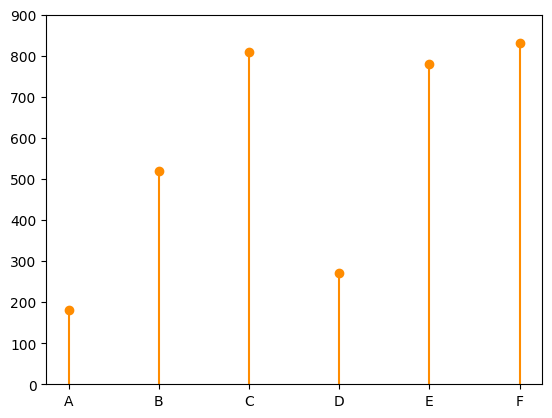

In [15]:
f, ax = plt.subplots()

# style the plot
style = {'c': 'darkorange'}

# draw the lines - naive solution
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
           **style)

# draw the ends 
ax.scatter(x=df['var1'], y=df['var2'], 
           **style)


ax.set_ylim([0, 900])

Usually, for `set_...` methods there is an associated `get_...` method: 

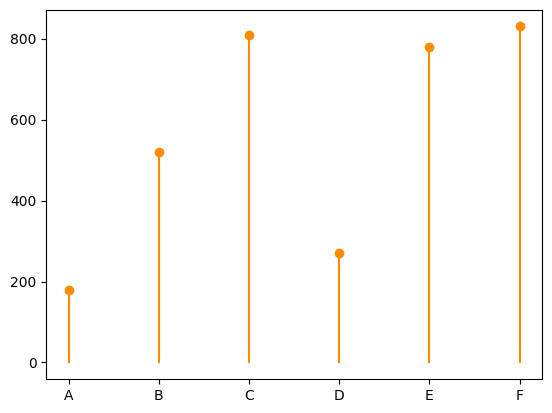

In [16]:
f, ax = plt.subplots()

# style the plot
style = {'c': 'darkorange'}

# draw the lines - naive solution
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
           **style)

# draw the ends 
ax.scatter(x=df['var1'], y=df['var2'], 
           **style)


my_ylims = ax.get_ylim()

In [17]:
print(my_ylims)

(np.float64(-41.5), np.float64(871.5))


Set the title and axis labels: 

Text(0, 0.5, 'Value')

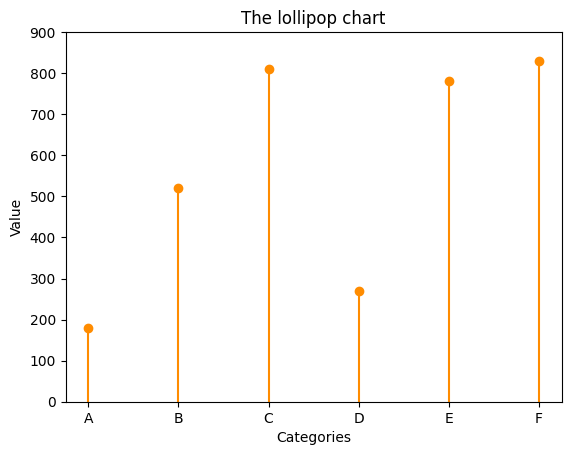

In [18]:
f, ax = plt.subplots()

# style the plot
style = {'c': 'darkorange'}

# draw the lines - naive solution
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
           **style)

# draw the ends 
ax.scatter(x=df['var1'], y=df['var2'], 
           **style)


ax.set_ylim([0, 900])

ax.set_title('The lollipop chart')
ax.set_xlabel('Categories')
ax.set_ylabel('Value')

The offset -> too small dpi (mpl centers things around pixels while drawing)

Change the aspect ratio, adjust dpi:

Text(0, 0.5, 'Value')

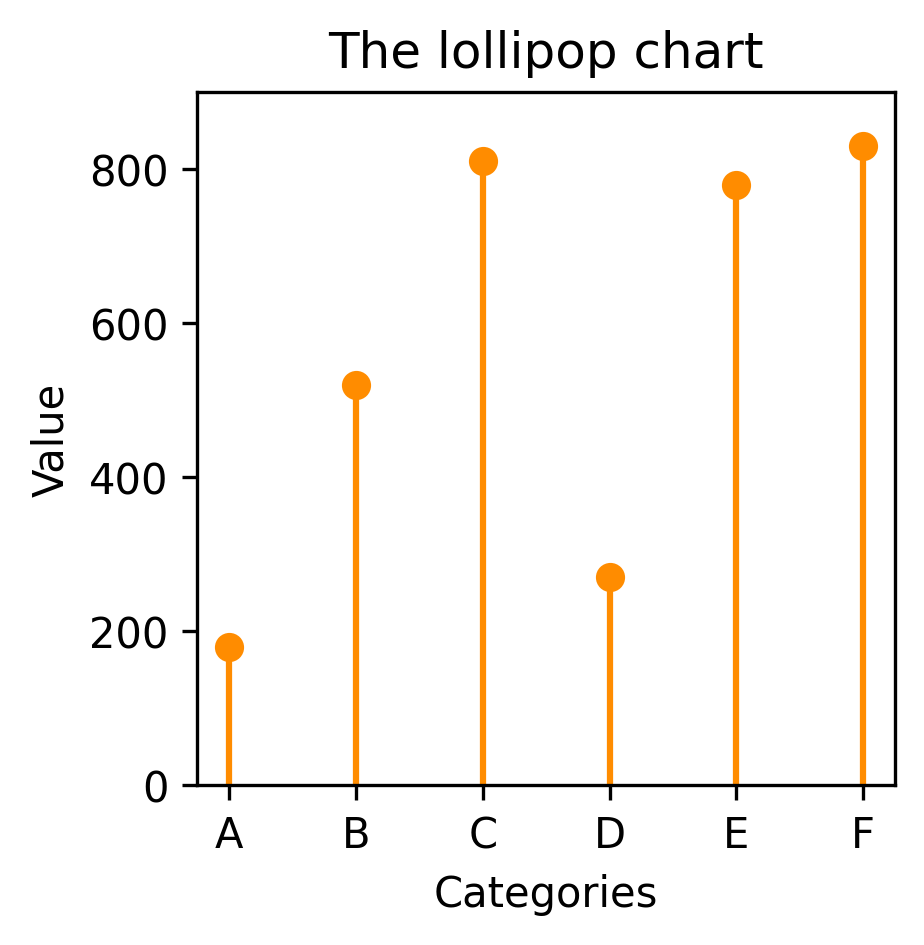

In [19]:
f, ax = plt.subplots(figsize=(3,3), dpi=300)

# style the plot
style = {'c': 'darkorange'}

# draw the lines - naive solution
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
           **style)

# draw the ends 
ax.scatter(x=df['var1'], y=df['var2'], 
           **style)


ax.set_ylim([0, 900])

ax.set_title('The lollipop chart')
ax.set_xlabel('Categories')
ax.set_ylabel('Value')

## Finished plot

Our code which saves the chart in a file

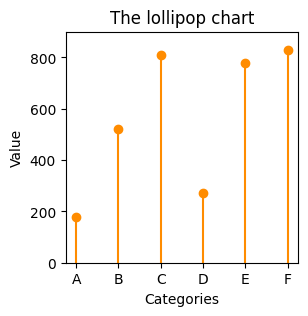

In [20]:
f, ax = plt.subplots(figsize=(3,3), dpi=100)

# style the plot
style = {'c': 'darkorange'}

# draw the lines - naive solution
for i in range(df.shape[0]):
    ax.plot([df['var1'][i], df['var1'][i]], 
            [0,df['var2'][i]], 
           **style)

# draw the ends 
ax.scatter(x=df['var1'], y=df['var2'], 
           **style)


ax.set_ylim([0, 900])

ax.set_title('The lollipop chart')
ax.set_xlabel('Categories')
ax.set_ylabel('Value')

f.savefig('reproduced_lollipop.png', dpi=300, bbox_inches='tight', facecolor='white')

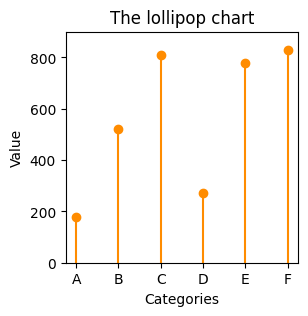

In [21]:
f

I can also save the same figure object in a different format (watch out if you are re-using your variable names and/or running the cells out of order!)

In [22]:
f.savefig('lollipop.pdf', bbox_inches='tight')

When saving to svg, by default your text will be rendered as curves - in order to keep text as text, change the `svg.fonttype` property. Experiment with importing both these svgs to Figma or Illustrator to see the difference. We will learn more about `rc_context` and `rc_params` next week.  

In [23]:
f.savefig('lollipop_outlines.svg', bbox_inches='tight')

with plt.rc_context({'svg.fonttype': 'none'}): 
    f.savefig('lollipop_text.svg', bbox_inches='tight')

___

# Your turn! 

Reproduce a simpler version of the correlation plot of the gambling data:

<img src="https://dk81.github.io/dkmathstats_site/rvisual-corrplots_files/figure-html/unnamed-chunk-7-1.png" width=300 />

<img src="corr_plot_example.png" width=300 />



In [24]:
corr_data = pd.read_csv('correlation_data.csv', sep=' ')

In [25]:
corr_data

,Sex,Status,Income,Verbal,Gamble
Sex,1.000000,-0.480935,-0.115459,-0.106976,-0.407805
Status,-0.480935,1.000000,-0.275034,0.531610,-0.050421
Income,-0.115459,-0.275034,1.000000,-0.175571,0.622077
Verbal,-0.106976,0.531610,-0.175571,1.000000,-0.220056
Gamble,-0.407805,-0.050421,0.622077,-0.220056,1.000000


Steps: 
- data transformation (e.g. pandas `unstack`, `reset_index`)
- scatter plot
- size and color (`darkred`, `dodgerblue`)
- axes limits 
- title 

In [26]:
# ...

# Solution 

In [27]:
corr_data2 = corr_data.unstack()\
    .rename('value')\
    .reset_index()

In [28]:
corr_data2['color'] = corr_data2.apply(lambda x: 'darkred' if x['value']<=0 else 'dodgerblue', axis=1)

In [29]:
corr_data2

,level_0,level_1,value,color
0,Sex,Sex,1.000000,dodgerblue
1,Sex,Status,-0.480935,darkred
2,Sex,Income,-0.115459,darkred
3,Sex,Verbal,-0.106976,darkred
4,Sex,Gamble,-0.407805,darkred
5,Status,Sex,-0.480935,darkred
6,Status,Status,1.000000,dodgerblue
7,Status,Income,-0.275034,darkred
8,Status,Verbal,0.531610,dodgerblue
9,Status,Gamble,-0.050421,darkred


Text(0.5, 1.0, 'Correlation plot of gambling data')

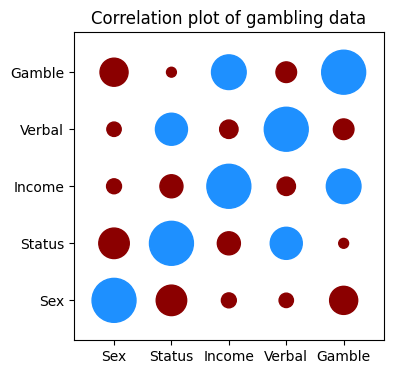

In [30]:
f, ax = plt.subplots(figsize=(4,4))

ax.scatter(x=corr_data2['level_0'], y=corr_data2['level_1'], 
           s=np.abs(corr_data2['value'])*1000, 
          c=corr_data2['color'])

margin = 0.5
ax.set_ylim(ax.get_ylim()[0]-margin, ax.get_ylim()[1]+margin)
ax.set_xlim(ax.get_xlim()[0]-margin, ax.get_xlim()[1]+margin)

ax.set_title('Correlation plot of gambling data')

# f.savefig('corr_plot_example.png', dpi=300, bbox_inches='tight')